In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, recall_score, precision_score
import seaborn as sns
from pathlib import Path
import os

In [39]:
sds_dir = Path('/Users/lukashat/sds_mount/sds/sd22c003/phenotyping_benchmark/visual_qc/corrected_annotations/')
dataset = 'IMMUcan'

In [40]:
dfs = []
for csv in os.listdir(os.path.join(sds_dir, dataset)):
    if csv.endswith('.csv'):
        df = pd.read_csv(os.path.join(sds_dir, dataset, csv))
        dfs.append(df)
full_df = pd.concat(dfs, ignore_index=True)

In [11]:
full_df

,CD45,CD20,dsDNA,pSLP-76,SLP-76,anti-H2AX (pS139),CD163,Histone H3,CD45RO,CD28,...,y,sample_id,level_1_cell_type,level_2_cell_type,cell_type,probability,NewAnnotation_Lukas,Reannotated,_is_dummy,cell_id
0,0.000000,0.005460,0.000247,0.0,0.0,0.000000,0.000000,0.222539,0.000332,0.000000,...,1261.0,1.csv,Immune,Lymphoid_immune,B_cell,1.0,NaN,False,False,23586
1,0.000000,0.001577,0.000000,0.0,0.0,0.000000,0.000000,0.208911,0.000051,0.000000,...,1261.0,1.csv,Immune,Lymphoid_immune,B_cell,1.0,NaN,False,False,23616
2,0.000000,0.000276,0.000000,0.0,0.0,0.000000,0.000000,0.147267,0.000000,0.000000,...,1262.0,1.csv,Immune,Lymphoid_immune,NK_cell,1.0,NaN,False,False,23639
3,0.000000,0.007751,0.000000,0.0,0.0,0.000000,0.000000,0.154699,0.000124,0.000000,...,1263.0,1.csv,Immune,Lymphoid_immune,B_cell,1.0,NaN,False,False,23670
4,0.000000,0.014449,0.000000,0.0,0.0,0.000000,0.000000,0.212461,0.000221,0.000000,...,1266.0,1.csv,Immune,Lymphoid_immune,B_cell,1.0,NaN,False,False,23681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,0.000981,0.000000,0.000000,0.0,0.0,0.000469,0.144613,0.100192,0.001510,0.000000,...,1984.0,3.csv,Immune,Myeloid_immune,M2_Macrophage,1.0,NaN,False,False,17825
898,0.001059,0.000000,0.000000,0.0,0.0,0.000000,0.017144,0.151911,0.000000,0.000000,...,1986.0,3.csv,Immune,Myeloid_immune,M2_Macrophage,1.0,NaN,False,False,17834
899,0.001191,0.000273,0.002276,0.0,0.0,0.000187,0.001297,0.113112,0.000064,0.000006,...,1988.0,3.csv,Immune,Lymphoid_immune,CD4+_T_cell,1.0,NaN,False,False,17877
900,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.004354,0.164960,0.000000,0.000000,...,1990.0,3.csv,unedfined,undefined,undefined,1.0,NaN,False,False,17878


In [41]:
# Expert review accuracy
# All cells were reviewed. Reannotated==True means expert changed the label.
# NewAnnotation_Lukas holds the correction; NaN means expert agreed with original.

orig_col = 'cell_type'
new_col  = 'NewAnnotation_Lukas'
flag_col = 'Reannotated'

df = full_df.copy()
df['expert_label'] = df.apply(
    lambda r: r[new_col] if r[flag_col] else r[orig_col], axis=1
)

overall_acc = (~df[flag_col]).mean()
print(f"Overall agreement (original GT vs expert): {overall_acc:.1%}  "
      f"({(~df[flag_col]).sum()} / {len(df)} cells)\n")

# Per-original-cell-type: how many were changed
per_type = (
    df.groupby(orig_col)[flag_col]
    .agg(n_cells='count', n_changed='sum')
    .assign(pct_changed=lambda d: d.n_changed / d.n_cells * 100)
    .sort_values('pct_changed', ascending=False)
)
print("Changes per original cell type:")
print(per_type.to_string())

# Confusion: original → expert correction (only changed cells)
changed = df[df[flag_col]]
if not changed.empty:
    print(f"\nOriginal → Expert correction (n={len(changed)}):")
    print(changed.groupby([orig_col, new_col]).size().rename('count').reset_index().to_string(index=False))


Overall agreement (original GT vs expert): 94.1%  (855 / 909 cells)

Changes per original cell type:
                             n_cells  n_changed  pct_changed
cell_type                                                   
BnT                                4          1    25.000000
Plasmacytoid_dendritic_cell       11          2    18.181818
CD4+_T_cell                       61          9    14.754098
Stroma                            65          4     6.153846
undefined                         51          3     5.882353
M2_Macrophage                    145          8     5.517241
Cancer                           372         20     5.376344
Neutrophil                        21          1     4.761905
Treg                              24          1     4.166667
CD8+_T_cell                      101          4     3.960396
Dendritic_cell                    27          1     3.703704
B_cell                             4          0     0.000000
NK_cell                            4         

In [42]:
if dataset == 'cHL_2_MIBI':
    cHL_2_MIBI = overall_acc
if dataset == 'IMMUcan':
    IMMUcan = overall_acc

In [14]:
IMMUcan

np.float64(0.9405940594059405)

In [44]:
df = pd.DataFrame({
    'Dataset': ['cHL_2_MIBI', 'IMMUcan', 'cHL_1_MIBI', 'cHL_CODEX', 'myeloma_IMC', 'Mouse Heart', 'healthy_bone_marrow', 'feto_maternal',
                'cycif_ovca', 'Breast_Jun0524', 'CRC_Feb2623', 'GVHD_Feb1323', 'Melanoma_Oct2522'],
    'Expert_1_agreement': [cHL_2_MIBI, IMMUcan] + [np.nan] * 11,
    'Expert_2_agreement': [np.nan] * 13
})

In [45]:
df

,Dataset,Expert_1_agreement,Expert_2_agreement
0,cHL_2_MIBI,0.913525,NaN
1,IMMUcan,0.940594,NaN
2,cHL_1_MIBI,NaN,NaN
3,cHL_CODEX,NaN,NaN
4,myeloma_IMC,NaN,NaN
5,Mouse Heart,NaN,NaN
6,healthy_bone_marrow,NaN,NaN
7,feto_maternal,NaN,NaN
8,cycif_ovca,NaN,NaN
9,Breast_Jun0524,NaN,NaN


/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_45660/3717605659.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


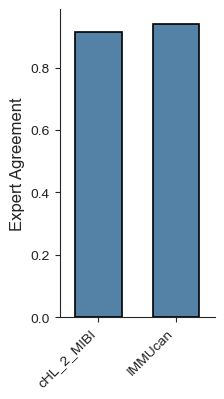

In [32]:
fig, ax = plt.subplots(figsize=(2, 4))
sns.set_style('ticks')

sns.barplot(
    data=df, x='Dataset', y='Expert Agreement',
    edgecolor='black', linewidth=1.2,
    width=0.6, color='steelblue', ax=ax
)
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Expert Agreement', fontsize=12)
sns.despine()

/var/folders/ry/jl4ll0zx1l709rh4r7_0cq6r0000gn/T/ipykernel_45660/1151022197.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


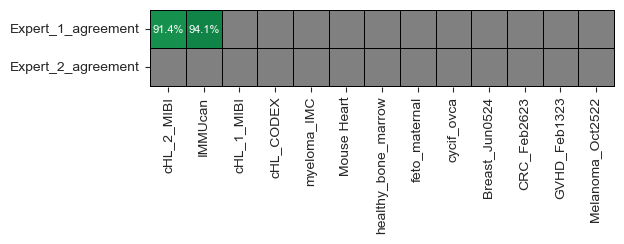

In [84]:
fig, ax = plt.subplots(figsize=(6, 1))
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad('grey')
sns.heatmap(
    df.set_index('Dataset')[['Expert_1_agreement', 'Expert_2_agreement']].T,
    annot=True, fmt=".1%", cmap=cmap, cbar=False, linewidths=0.5, linecolor='black', vmax=1.0, vmin=0.0, annot_kws={"size": 8},
    ax=ax
)
ax.set_ylim(2.02, -0.02)
ax.set_xlim(-0.02, len(df) + 0.02)
ax.set_xlabel('')
fig.tight_layout()
fig.savefig('/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/stage_1/revision/plots/expert_agreement_heatmap.svg',bbox_inches='tight', dpi=300)